# Bank Customer Churn EDA

This notebook performs an exploratory data analysis (EDA) on the Bank Customer Churn dataset. The goal is to understand the structure of the data, identify important patterns, and summarize key insights that may help explain customer churn.

## 1. Importing Libraries

We begin by importing the libraries needed for data loading, analysis, and visualization.

In [32]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Improve visual style for better readability
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")

# Display more columns in notebook output
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Loading the Dataset

The dataset is loaded from the raw data folder. A small fallback is included to support the notebook when run from different working directories.

In [33]:
# Locate the dataset using a robust relative path
raw_path = Path("../datasets/raw/Churn_Modelling.csv")
if not raw_path.exists():
    raw_path = Path("../../datasets/raw/Churn_Modelling.csv")

if not raw_path.exists():
    raise FileNotFoundError(f"Dataset not found at expected locations: {raw_path}")

# Load the dataset
try:
    df = pd.read_csv(raw_path)
    print(f"Dataset loaded successfully from: {raw_path}")
except Exception as e:
    raise RuntimeError(f"Failed to load dataset: {e}")

# Display the first few rows
print("\nPreview of the dataset:\n")
df.head()

Dataset loaded successfully from: ..\..\datasets\raw\Churn_Modelling.csv

Preview of the dataset:



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Dataset Preview and Basic Structure

We inspect the first and last few rows to confirm the dataset contents and understand the columns.

In [34]:
# Show the first and last 5 rows
print("First 5 rows:")
df.head()

print("\nLast 5 rows:")
df.tail()

First 5 rows:

Last 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


## 4. Dataset Shape and Information

This section helps us understand the size of the dataset and the data types of each feature.

In [35]:
# Dataset shape
print("Dataset shape:", df.shape)

# Dataset information
print("\nDataset information:\n")
df.info()

Dataset shape: (10000, 14)

Dataset information:

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


## 5. Descriptive Statistics

Summary statistics provide a quick overview of the numerical columns, including central tendency and spread.

In [36]:
# Statistical summary for numerical features
print("Descriptive statistics:\n")
df.describe().T

Descriptive statistics:



,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


## 6. Missing Values and Duplicates

We check for missing values and duplicate rows to ensure the dataset is clean before deeper analysis.

In [37]:
# Missing values analysis
missing_values = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)
missing_report = pd.DataFrame({"Missing Count": missing_values, "Missing %": missing_percent})
missing_report = missing_report[missing_report["Missing Count"] > 0]

print("Missing values report:")
if missing_report.empty:
    print("No missing values found.")
else:
    display(missing_report)

# Duplicate values analysis
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

Missing values report:
No missing values found.

Number of duplicate rows: 0


## 7. Numerical and Categorical Columns

We separate the columns into numerical and categorical groups for more targeted analysis.

In [38]:
# Identify numerical columns
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

# Identify categorical columns (object-like columns)
categorical_columns = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Categorical columns:
['Surname', 'Geography', 'Gender']


## 8. Target Variable Distribution

The target column is Exited, which indicates whether a customer churned. We analyze its distribution to understand class balance.

Target distribution:
        Count  Percentage
Exited                   
0        7963       79.63
1        2037       20.37


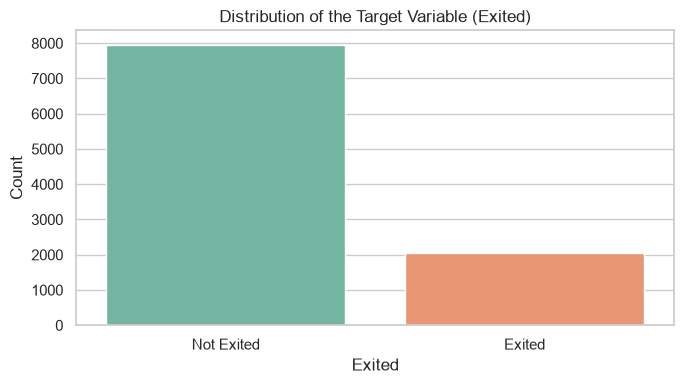

In [39]:
# Target variable distribution
target_counts = df["Exited"].value_counts()
target_percent = df["Exited"].value_counts(normalize=True) * 100

print("Target distribution:")
print(pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent.round(2)
}))

# Visualize target distribution
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="Exited",
    hue="Exited",
    palette="Set2",
    legend=False
)

plt.title("Distribution of the Target Variable (Exited)")
plt.xlabel("Exited")
plt.ylabel("Count")
plt.xticks([0, 1], ["Not Exited", "Exited"])
plt.tight_layout()
plt.show()

## 9. Histograms for Numerical Features

Histograms help us inspect the distribution of each numerical feature and identify skewness or unusual value ranges.

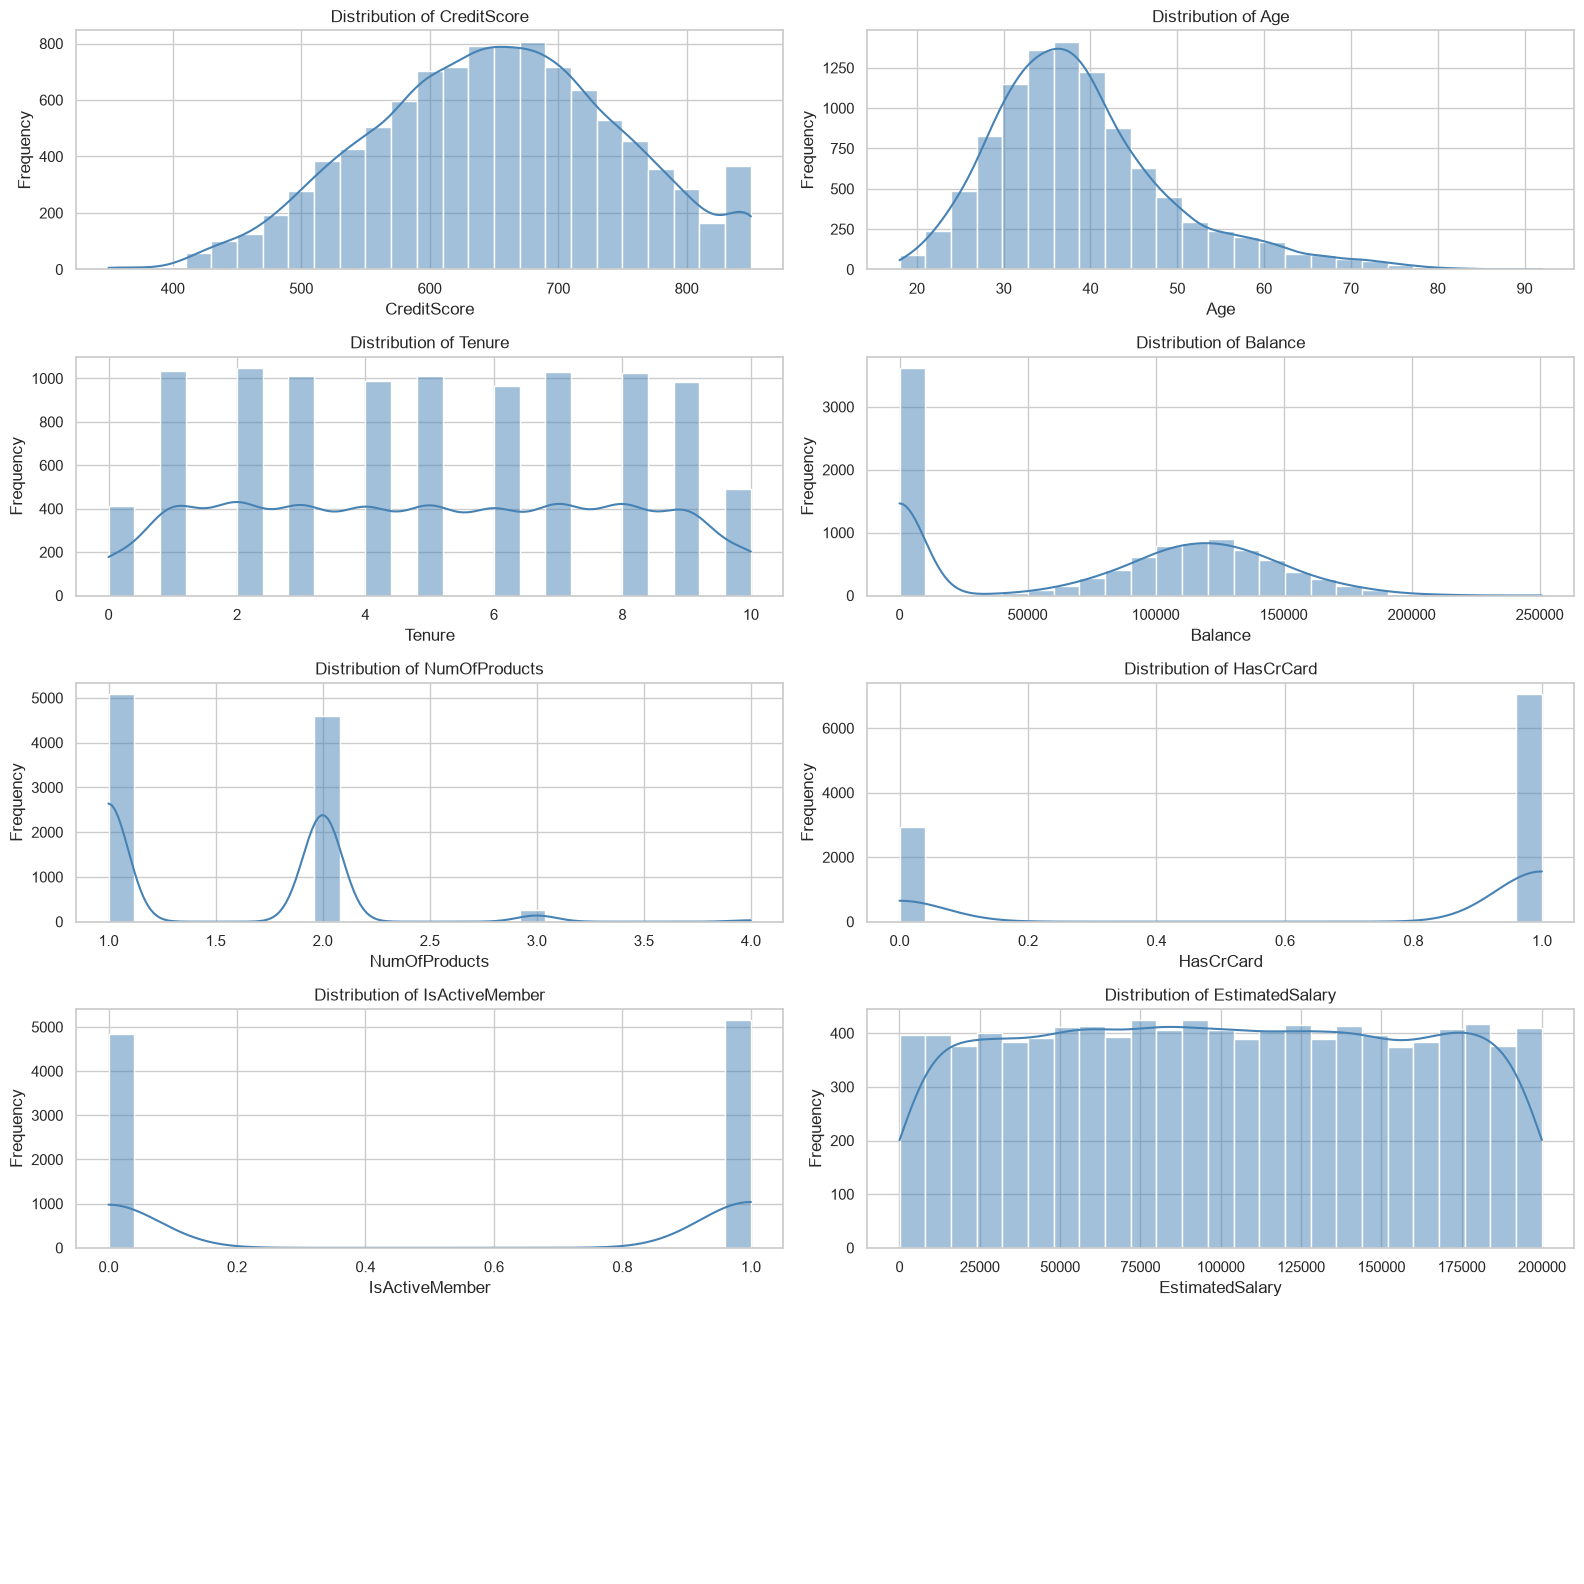

In [40]:
# Plot histograms for key numerical features
hist_features = [col for col in numeric_columns if col not in ["RowNumber", "CustomerId", "Exited"]]

fig, axes = plt.subplots(len(hist_features) // 2 + 1, 2, figsize=(16, 16))
axes = axes.flatten()

for ax, feature in zip(axes, hist_features):
    sns.histplot(df[feature], bins=25, kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

# Hide any empty subplots
for ax in axes[len(hist_features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 10. Boxplots for Outlier Detection

Boxplots are useful for identifying outliers and comparing the spread of values across important features.

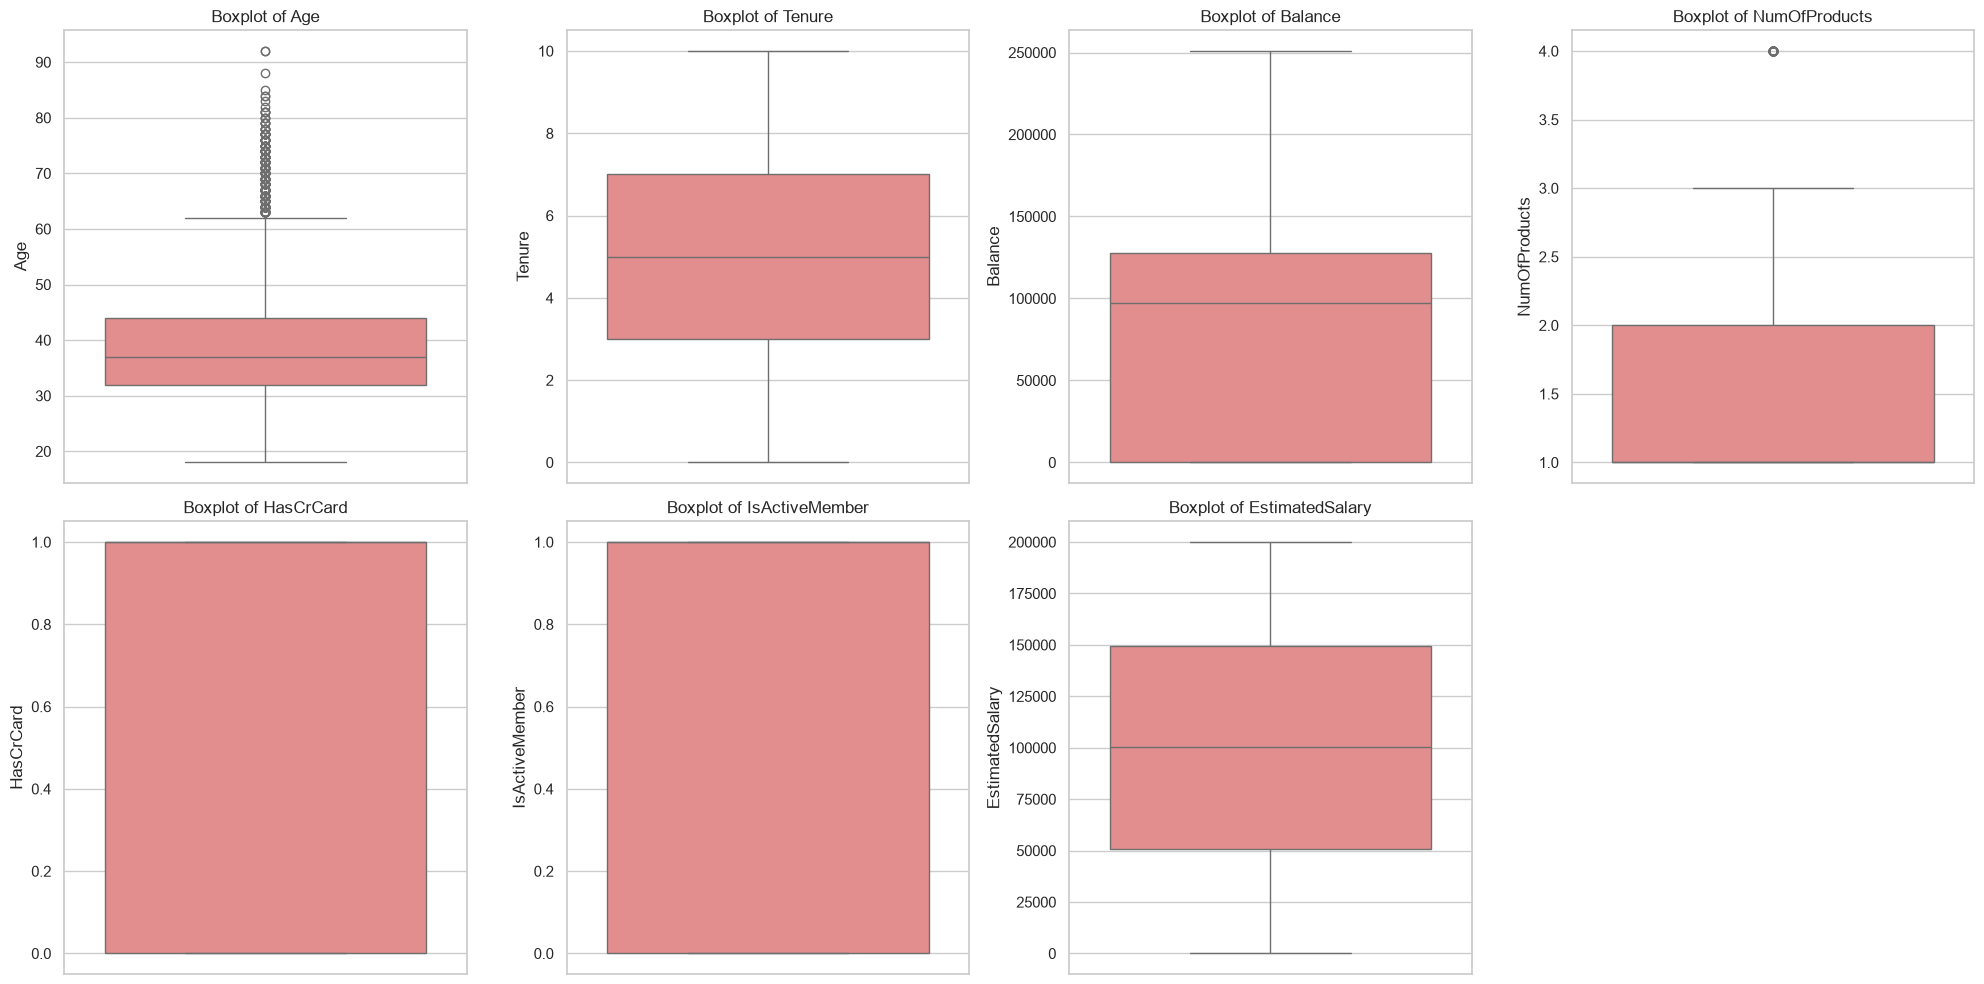

In [41]:
# Boxplots for selected numerical features
box_features = [col for col in hist_features if col != "CreditScore"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, feature in zip(axes, box_features):
    sns.boxplot(y=df[feature], ax=ax, color="lightcoral")
    ax.set_title(f"Boxplot of {feature}")
    ax.set_ylabel(feature)

# Hide any empty subplots
for ax in axes[len(box_features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 11. Correlation Heatmap

A correlation heatmap helps us see which numerical variables are strongly related to each other.

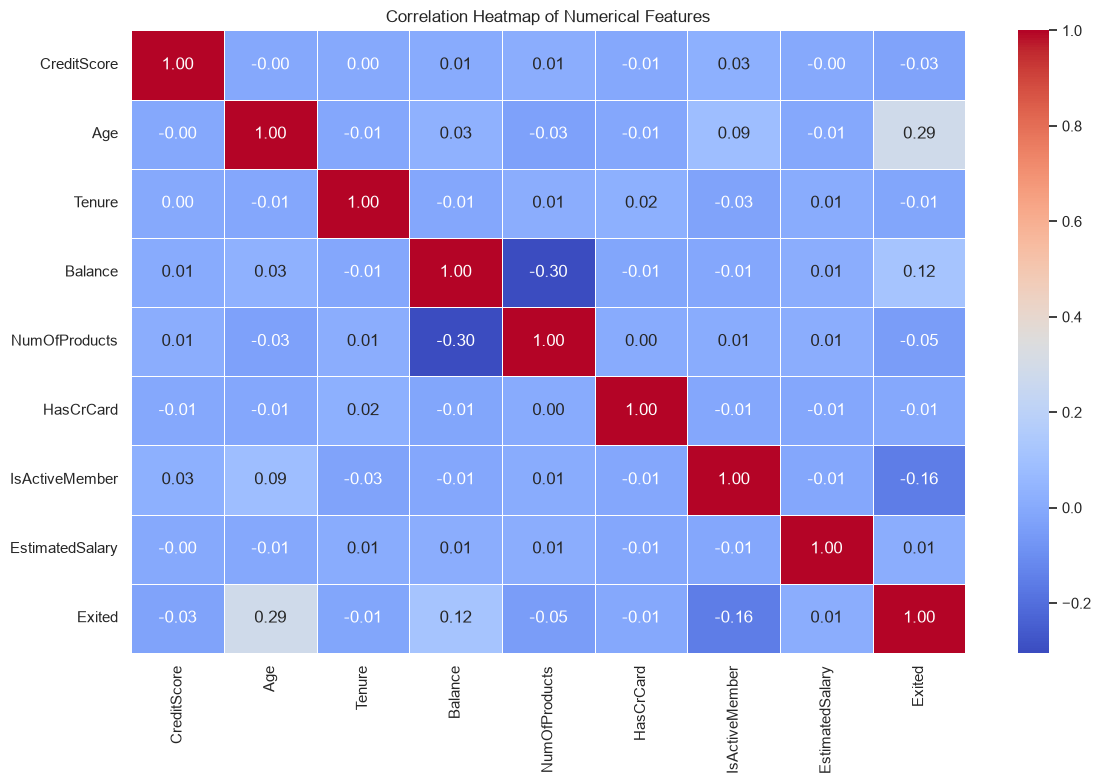

In [42]:
# Create a correlation matrix for numerical features
correlation_features = [col for col in numeric_columns if col not in ["RowNumber", "CustomerId"]]
correlation_matrix = df[correlation_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

## 12. Count Plots for Categorical Features

Count plots help us understand the distribution of categorical variables such as geography and gender.

C:\Users\MITHRA\AppData\Local\Temp\ipykernel_48164\587792036.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="pastel", ax=ax)
C:\Users\MITHRA\AppData\Local\Temp\ipykernel_48164\587792036.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="pastel", ax=ax)


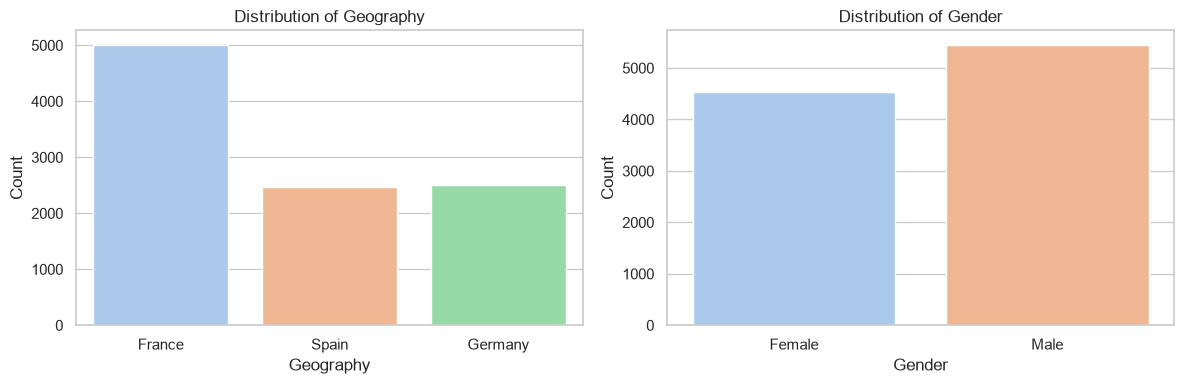

In [43]:
# Plot categorical distributions for selected columns
plot_columns = [col for col in categorical_columns if col in ["Geography", "Gender"]]

fig, axes = plt.subplots(1, len(plot_columns), figsize=(12, 4))
if len(plot_columns) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_columns):
    sns.countplot(data=df, x=col, palette="pastel", ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## 13. Pairplot for Important Numerical Features

A pairplot gives a quick visual summary of relationships between several important numerical features.

<Figure size 1400x1000 with 0 Axes>

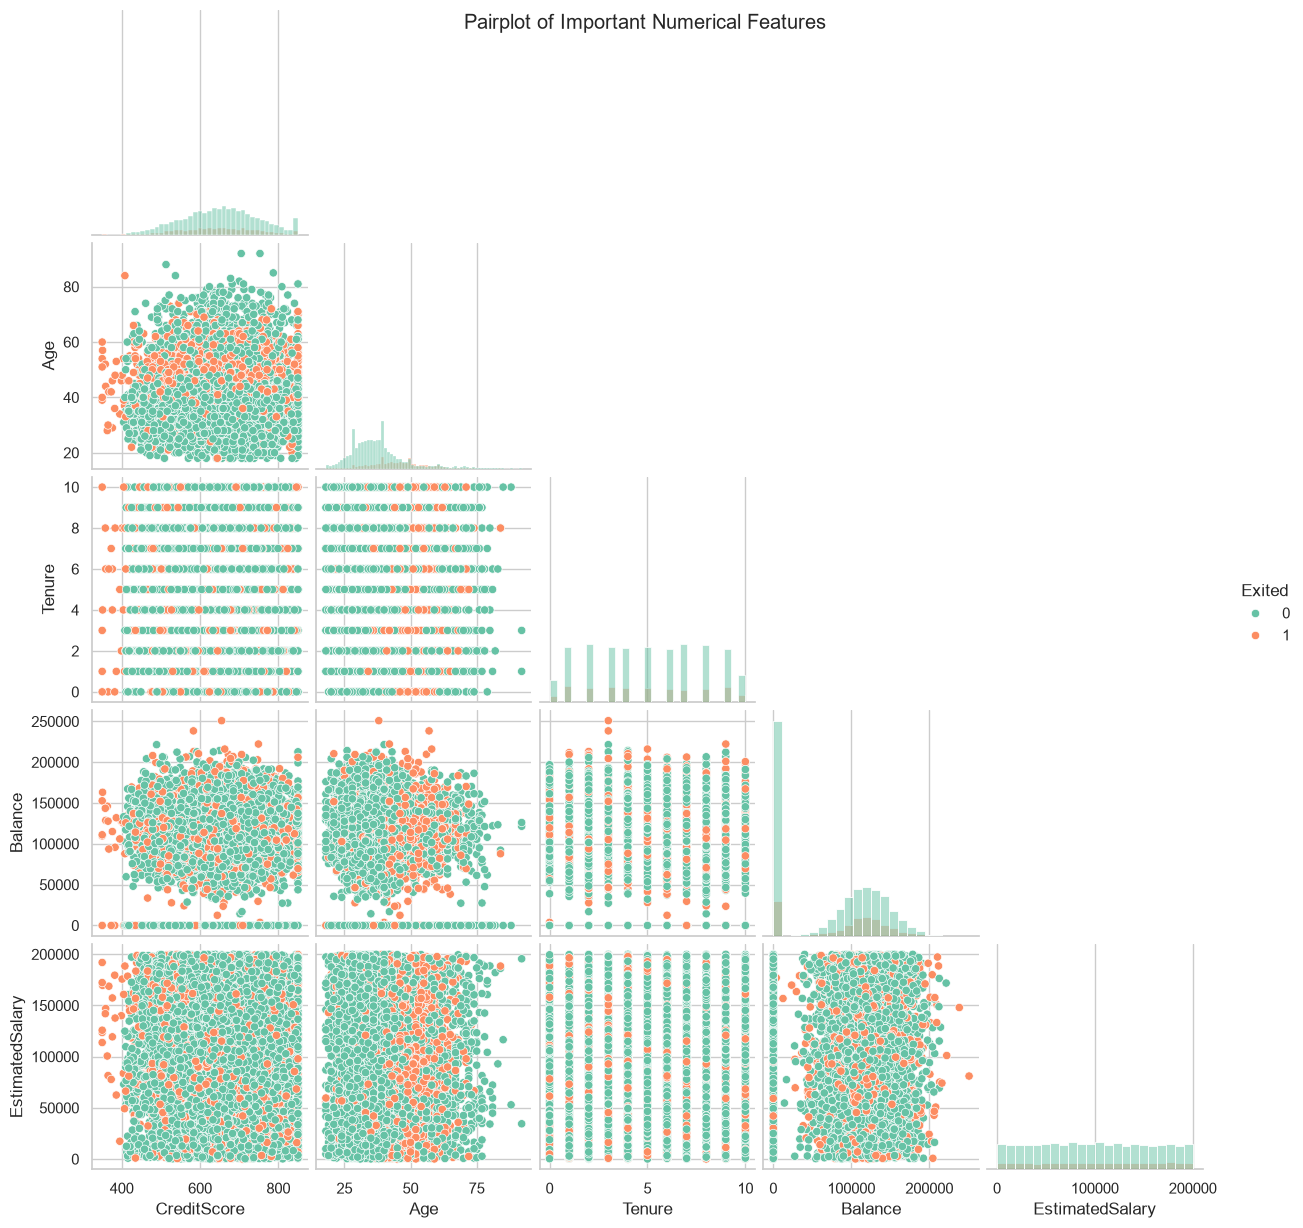

In [44]:
# Create a pairplot for a meaningful subset of numerical variables
pairplot_features = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary", "Exited"]

pairplot_df = df[pairplot_features].copy()

plt.figure(figsize=(14, 10))
sns.pairplot(pairplot_df, hue="Exited", diag_kind="hist", corner=True, palette="Set2")
plt.suptitle("Pairplot of Important Numerical Features")
plt.show()

## 14. Feature-wise Observations

Based on the visualizations and summary statistics, we can note a few initial observations about the dataset.

In [45]:
# Generate simple feature-wise observations
print("Feature-wise observations:\n")

# Average churn rate
overall_churn_rate = df["Exited"].mean()
print(f"- Overall churn rate: {overall_churn_rate:.2%}")

# Churn by geography
geography_churn = df.groupby("Geography")["Exited"].mean().sort_values(ascending=False)
print("\n- Churn rate by geography:")
print(geography_churn.round(4))

# Churn by gender
gender_churn = df.groupby("Gender")["Exited"].mean().sort_values(ascending=False)
print("\n- Churn rate by gender:")
print(gender_churn.round(4))

# Churn by active membership
active_churn = df.groupby("IsActiveMember")["Exited"].mean()
print("\n- Churn rate by active membership status:")
print(active_churn.round(4))

# Average age by target
age_by_target = df.groupby("Exited")["Age"].mean()
print("\n- Average age by target:")
print(age_by_target.round(2))

Feature-wise observations:

- Overall churn rate: 20.37%

- Churn rate by geography:
Geography
Germany    0.3244
Spain      0.1667
France     0.1615
Name: Exited, dtype: float64

- Churn rate by gender:
Gender
Female    0.2507
Male      0.1646
Name: Exited, dtype: float64

- Churn rate by active membership status:
IsActiveMember
0    0.2685
1    0.1427
Name: Exited, dtype: float64

- Average age by target:
Exited
0    37.41
1    44.84
Name: Age, dtype: float64


## 15. Overall EDA Conclusions

This final section summarizes the main insights discovered during the exploratory analysis.

In [46]:
# Final EDA conclusions
print("Overall EDA conclusions:\n")
print("1. The dataset contains customer demographic, account, and churn-related information.")
print("2. The target variable Exited is imbalanced, so churn analysis should be interpreted carefully.")
print("3. Numerical features such as Age, Balance, and EstimatedSalary show interesting distributions and may be relevant for predicting churn.")
print("4. Categorical features such as Geography and Gender show different churn patterns across groups.")
print("5. The dataset appears to be relatively clean, with no missing values or duplicate rows in this version.")
print("6. Further analysis can focus on feature relationships with Exited and the development of predictive models.")

Overall EDA conclusions:

1. The dataset contains customer demographic, account, and churn-related information.
2. The target variable Exited is imbalanced, so churn analysis should be interpreted carefully.
3. Numerical features such as Age, Balance, and EstimatedSalary show interesting distributions and may be relevant for predicting churn.
4. Categorical features such as Geography and Gender show different churn patterns across groups.
5. The dataset appears to be relatively clean, with no missing values or duplicate rows in this version.
6. Further analysis can focus on feature relationships with Exited and the development of predictive models.
